<a href="https://colab.research.google.com/github/JustmeLu/Tareas-automatizacionInicial/blob/main/2-Ejercicios/06-SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/andres-merino/AprendizajeAutomaticoInicial-05-N0105/blob/main/2-Ejercicios/06-SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/nt7hloA.png" width="100">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#0030A1" size="7">|</font><br>
            <font color="#0030A1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="5">
                <b>Facultad de Ciencias Exactas, Naturales y Ambientales</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="4">
                Aprendizaje Automático Inicial &bull; Máquinas de soporte vectorial
            </font></p>
            <p style="font-style: oblique;"><font color="#0030A1" size="3">
                Luisa Guerrero &bull; 2026-04-01
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='264CC7'> Introducción </font>

A lo largo de este taller, aplicaremos el algoritmo de máquinas de soporte vectorial (SVM) para clasificar un conjunto de datos.

Los paquetes necesarios son:

In [20]:
# Paquetes necesarios
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np


---
## <font color='264CC7'> Clasificación </font>


### <font color='264CC7'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase anterior.

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [10]:
data = pd.read_csv("drug200.csv")

print(data.head())




   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  DrugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  DrugY


In [11]:
# Descripción de los datos
print(data.describe(include="all"))



               Age  Sex    BP Cholesterol     Na_to_K   Drug
count   200.000000  200   200         200  200.000000    200
unique         NaN    2     3           2         NaN      5
top            NaN    M  HIGH        HIGH         NaN  DrugY
freq           NaN  104    77         103         NaN     91
mean     44.315000  NaN   NaN         NaN   16.084485    NaN
std      16.544315  NaN   NaN         NaN    7.223956    NaN
min      15.000000  NaN   NaN         NaN    6.269000    NaN
25%      31.000000  NaN   NaN         NaN   10.445500    NaN
50%      45.000000  NaN   NaN         NaN   13.936500    NaN
75%      58.000000  NaN   NaN         NaN   19.380000    NaN
max      74.000000  NaN   NaN         NaN   38.247000    NaN


In [12]:

data = pd.get_dummies(data, columns=["Sex", "BP", "Cholesterol"], drop_first=True)

# Escalar variables numéricas
scaler = StandardScaler()
data[["Age", "Na_to_K"]] = scaler.fit_transform(data[["Age", "Na_to_K"]])

print(data.head())

        Age   Na_to_K   Drug  Sex_M  BP_LOW  BP_NORMAL  Cholesterol_NORMAL
0 -1.291591  1.286522  DrugY  False   False      False               False
1  0.162699 -0.415145  drugC   True    True      False               False
2  0.162699 -0.828558  drugC   True    True      False               False
3 -0.988614 -1.149963  drugX  False   False       True               False
4  1.011034  0.271794  DrugY  False    True      False               False



### <font color='264CC7'> Determinación del mejor kernel </font>

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Determina el mejor kernel para el modelo SVM.
<ul>
  <li>Genera una gráfica que muestre la precisión de los modelos con diferentes kernels.</li>
  <li>Selecciona el mejor kernel.</li>
</ul>
</div>


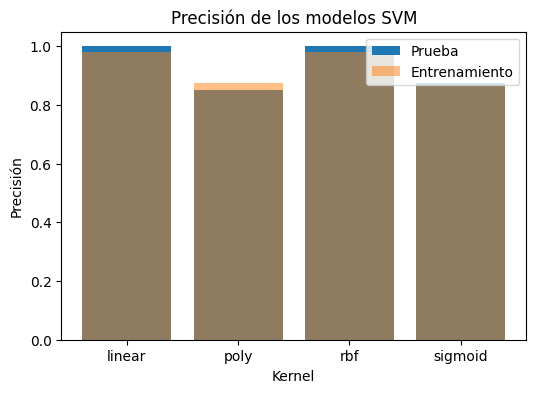

Mejor kernel: linear


In [15]:
X = data.drop("Drug", axis=1)
y = data["Drug"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

kernel_values = ["linear", "poly", "rbf", "sigmoid"]
precisions_test = []
precisions_train = []

for kernel in kernel_values:
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)

    precisions_test.append(
        accuracy_score(y_test, model.predict(X_test))
    )
    precisions_train.append(
        accuracy_score(y_train, model.predict(X_train))
    )

plt.figure(figsize=(6,4))
plt.bar(kernel_values, precisions_test)
plt.bar(kernel_values, precisions_train, alpha=0.5)
plt.xlabel("Kernel")
plt.ylabel("Precisión")
plt.title("Precisión de los modelos SVM")
plt.legend(["Prueba", "Entrenamiento"])
plt.show()

best_kernel = kernel_values[precisions_test.index(max(precisions_test))]
print("Mejor kernel:", best_kernel)


El mejor Kernel, el cual eligo es el Linear ya que  con los datos de prueba llegan a la maxima presición  en lso datos de prueb, entonces esto significa q al tener neuvos datos el modleo no comete errores


### <font color='264CC7'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo con el kernel seleccionado.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Genera una matriz de confusión y muestra las métricas de evaluación.</li>
</ul>
</div>

In [18]:
# Entrenar modelo
model = SVC(kernel=best_kernel)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Evaluación
print("Precisión del modelo:", round(accuracy_score(y_test, y_pred), 2))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))








Precisión del modelo: 1.0
Matriz de confusión:
[[18  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  3  0]
 [ 0  0  0  0 11]]
Reporte de clasificación:
              precision    recall  f1-score   support

       DrugY       1.00      1.00      1.00        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



El modelo SVM con el kernel lineal tiene  una precisión de 1.0 en el conjunto de prueba eso significa que clasificó correctamente todos los registros. Esto tambien se puede ver  en la matriz de confusión donde no hay errores y todas las predicciones estan en la diagonal principal. Además, las métricas de precisión, recall y f1-score son iguales a 1.00 para todas las clases.

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Compara el modelo con otros algoritmos de clasificación vistos en clases anteriores.
</div>

In [21]:
#  SVM (ya entrenado antes como model)
svm_acc = accuracy_score(y_test, model.predict(X_test))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))

# KMeans (clustering → asignación por mayoría)
kmeans = KMeans(n_clusters=y.nunique(), random_state=42)
kmeans.fit(X_train)

# Asignar etiquetas por mayoría
cluster_labels = {}
for c in np.unique(kmeans.labels_):
    idx = np.where(kmeans.labels_ == c)
    cluster_labels[c] = y_train.iloc[idx].mode()[0]

y_kmeans_pred = [cluster_labels[c] for c in kmeans.predict(X_test)]
kmeans_acc = accuracy_score(y_test, y_kmeans_pred)

# Resultados
print("Precisión SVM:", svm_acc)
print("Precisión KNN:", knn_acc)
print("Precisión KMeans:", kmeans_acc)


Precisión SVM: 1.0
Precisión KNN: 0.8
Precisión KMeans: 0.475


Los resultados muestran diferencias entre los modelos. El SVM tiene una precisión de 1.0, lo que significa que clasificó correctamente todos los datos de prueba, por lo que se pdoria decir q es el mejor modelo. El KNN tiene una precisión de 0.8, osea tuvo un buen desempeño, pero cometió algunos errores, ya que su resultado depende mucho de cómo estén distribuidos los datos y del número de vecinos elegido. En cambio, K-Means obtuvo una precisión de 0.475 q es bastante más baja, lo cual es normal porque este método no usa las etiquetas reales y solo agrupa los datos según similitud. Entonces para este problema, los modelos supervisados funcionan mejor y el SVM fue la mejor opción.